# Proof of Concept with OpenCV 01

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import itertools as it

In [19]:
def show_image(image):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()

## Load Image

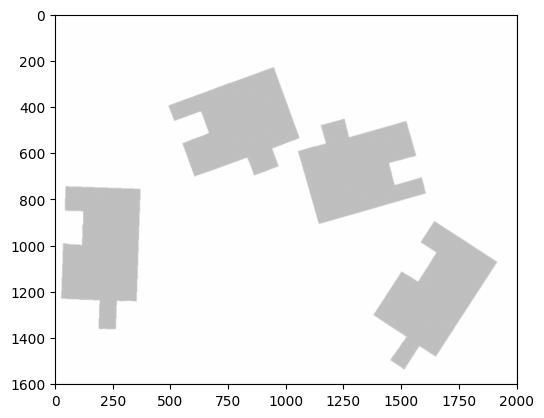

In [20]:
image = cv2.imread("../assets/puzzle_images/simulator_01.png")
show_image(image)

## Object Detection

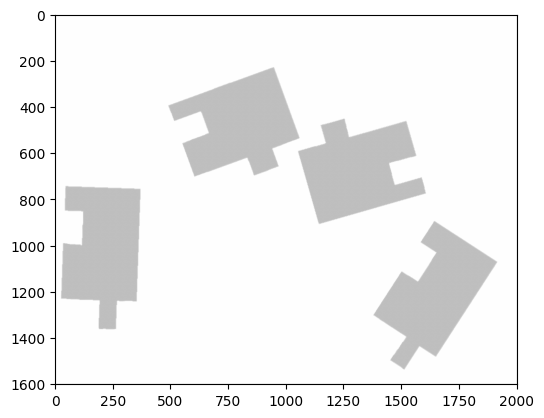

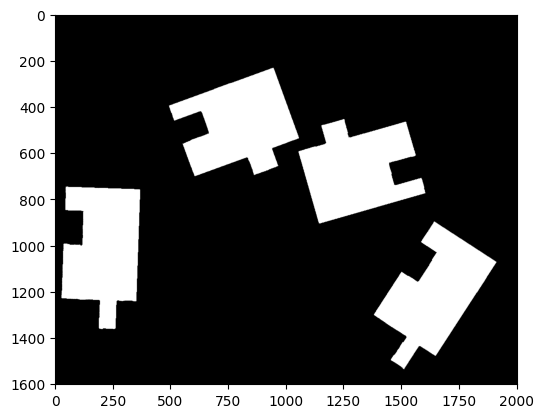

In [21]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
show_image(gray_image)

_, thresh = cv2.threshold(gray_image, 200, 255, cv2.THRESH_BINARY_INV)
show_image(thresh)

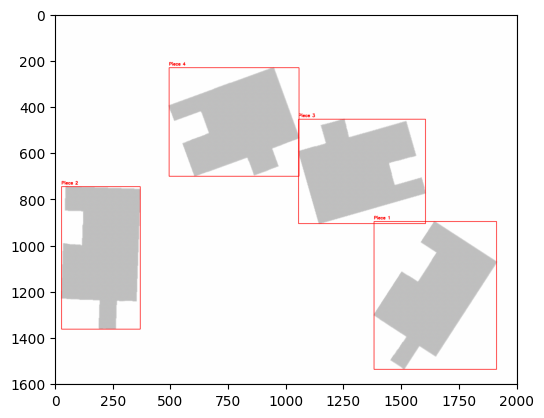

In [22]:
def draw_bounding_boxes(image, boxes):
    image = np.copy(image)

    for box in boxes:
        x1, y1, x2, y2 = [int(coord) for coord in box]
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 10)

    return image

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

pieces_image = image.copy()
for i, c in enumerate(contours):
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(pieces_image, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.putText(pieces_image, f"Piece {i+1}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

show_image(pieces_image)

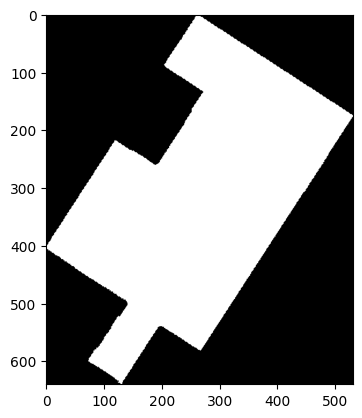

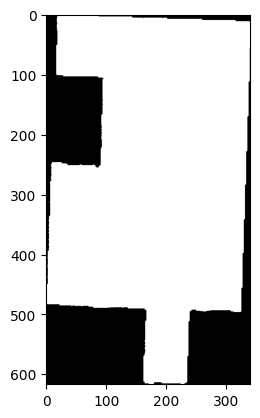

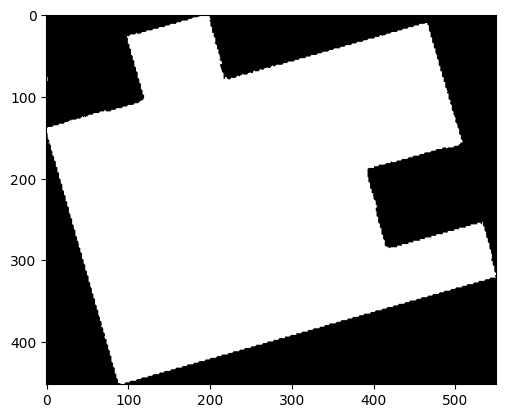

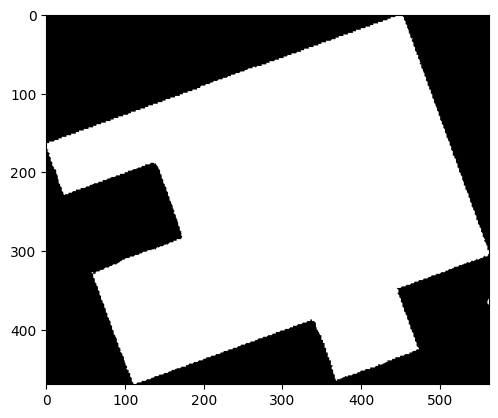

In [23]:
pieces = []

for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    piece = thresh[y:y+h, x:x+w]
    pieces.append(piece)

    show_image(piece)

## Corner Detection

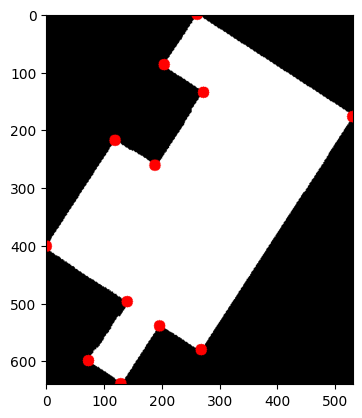

In [ ]:
example_piece = pieces[0]

piece_contour, _ = cv2.findContours(example_piece, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
piece_contour = piece_contour[0]

epsilon = 0.01 * cv2.arcLength(piece_contour, True)
approx = cv2.approxPolyDP(piece_contour, epsilon, True)

corners = []
example_piece_image = cv2.cvtColor(example_piece.copy(), cv2.COLOR_GRAY2RGB)
for (x, y) in approx.reshape(-1, 2):
    corners.append((x, y))
    cv2.circle(example_piece_image, (x, y), 10, (0, 0, 255), -1)

show_image(example_piece_image)

The following is not working well

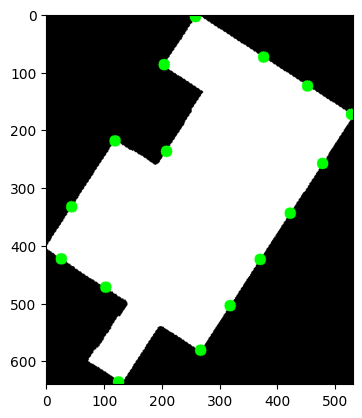

In [25]:
corners = cv2.goodFeaturesToTrack(example_piece, maxCorners=50, qualityLevel=0.05, minDistance=90)
corners = np.astype(corners, int)

example_piece_image = cv2.cvtColor(example_piece.copy(), cv2.COLOR_GRAY2RGB)
for c in corners:
    x, y = c.ravel()
    cv2.circle(example_piece_image, (x, y), 10, (0, 255, 0), -1)

show_image(example_piece_image)

## Detecting the 4 Piece Corners

This is not _yet_ working reliably...

In [ ]:
# Corresponds to euclidian distance
def distance(p1, p2):
    return np.linalg.norm(np.array(p1)-np.array(p2))

distances = []
for p1, p2 in it.combinations(corners, 2):
    dist = distance(p1, p2)
    distances.append((p1, p2, dist))

distances.sort(key=lambda v: v[2], reverse=True)
distances

[((np.int32(261), np.int32(0)),
  (np.int32(129), np.int32(639)),
  np.float64(652.4913792533968)),
 ((np.int32(261), np.int32(0)),
  (np.int32(73), np.int32(599)),
  np.float64(627.8096845382365)),
 ((np.int32(73), np.int32(599)),
  (np.int32(530), np.int32(177)),
  np.float64(622.0393878204177)),
 ((np.int32(129), np.int32(639)),
  (np.int32(530), np.int32(177)),
  np.float64(611.7556701821406)),
 ((np.int32(261), np.int32(0)),
  (np.int32(268), np.int32(580)),
  np.float64(580.0422398412032)),
 ((np.int32(0), np.int32(401)),
  (np.int32(530), np.int32(177)),
  np.float64(575.3920402647225)),
 ((np.int32(204), np.int32(87)),
  (np.int32(129), np.int32(639)),
  np.float64(557.0718086566578)),
 ((np.int32(261), np.int32(0)),
  (np.int32(196), np.int32(539)),
  np.float64(542.9051482533574)),
 ((np.int32(204), np.int32(87)),
  (np.int32(73), np.int32(599)),
  np.float64(528.4931409204854)),
 ((np.int32(272), np.int32(135)),
  (np.int32(129), np.int32(639)),
  np.float64(523.894073262906

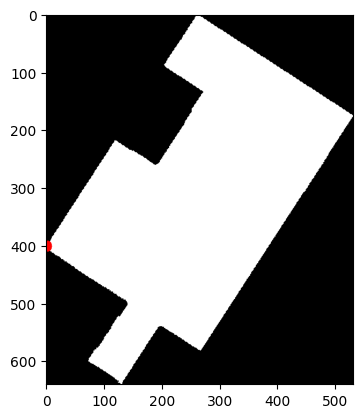

In [ ]:
# Assumes all corners were detected (RISK)
# THIS IS WRONG
diag1 = distances[0]
diag2 = distances[1]

len1 = distances[2]
len2 = distances[3]
wid1 = distances[4]
wid2 = distances[5]

# Here we could test if the detected corners touch each other

example_piece_image = cv2.cvtColor(example_piece.copy(), cv2.COLOR_GRAY2RGB)
cv2.circle(example_piece_image, wid2[0], 10, (0, 0, 255), -1)
show_image(example_piece_image)